# 🎯 RFM-Based Customer Segmentation for Retail Transactions
### Advanced Customer Segmentation using RFM Analysis, Statistical Cluster Validation & K-Means Clustering

**Disusun oleh:** Muhammad Febriyan Putrahariska (20230801043)
**Mata Kuliah:** Data Mining
**Dataset:** Online Retail Transaction Dataset

---

## 📋 Ringkasan Eksekutif (Executive Summary)

Proyek ini membangun sistem **segmentasi pelanggan berbasis perilaku transaksi (behavioral customer segmentation)** untuk bisnis retail, menggunakan pendekatan **RFM (Recency, Frequency, Monetary)** yang dikombinasikan dengan **unsupervised machine learning (K-Means Clustering)**.

Berbeda dengan pendekatan sederhana *"pakai K-Means untuk clustering customer"*, proyek ini dibangun sebagai **pipeline data science end-to-end** yang mencakup data cleaning yang ketat, rekayasa fitur RFM, penanganan skewness & outlier secara statistik, **validasi jumlah cluster dengan 3+ metrik kuantitatif** (bukan hanya satu angka silhouette), profiling cluster yang mendalam, interpretasi segmen berbasis aturan bisnis, visualisasi PCA, hingga **rekomendasi strategi bisnis yang actionable** per segmen.

### 🔄 Alur Metodologi (Pipeline)

```
Raw Transaction Data
        ↓
Data Cleaning
        ↓
RFM Feature Engineering
        ↓
Standardization (Log Transform + StandardScaler)
        ↓
Outlier Analysis (Z-Score based)
        ↓
Optimal K Selection (Elbow + Silhouette + Calinski-Harabasz + Davies-Bouldin)
        ↓
K-Means Clustering
        ↓
Cluster Profiling
        ↓
Business Segment Interpretation
        ↓
PCA 2D Visualization
        ↓
Business Recommendations
```

### 🎯 Tujuan Analisis
1. Mengidentifikasi **segmen pelanggan** berdasarkan perilaku transaksi historis (kapan terakhir belanja, seberapa sering, seberapa besar nilai belanja).
2. Menentukan **jumlah cluster optimal** secara objektif menggunakan kombinasi metrik statistik, bukan hanya mengandalkan satu metrik yang bisa menyesatkan (misalnya silhouette score yang tinggi di k=2 akibat pembagian yang terlalu sederhana/trivial).
3. Menerjemahkan hasil cluster matematis menjadi **segmen bisnis yang bisa ditindaklanjuti** (Champions, Loyal Customers, At Risk, dsb).
4. Memberikan **rekomendasi strategi pemasaran** yang spesifik untuk tiap segmen, lengkap dengan estimasi kontribusi pendapatan.

> 💡 **Catatan penting soal pemilihan k:** Silhouette score tertinggi tidak otomatis berarti solusi terbaik secara bisnis. k=2 sering menghasilkan silhouette score yang tinggi karena hanya memisahkan data menjadi "kelompok besar vs outlier kecil" — secara matematis rapi, tapi tidak actionable untuk strategi pemasaran yang membutuhkan granularitas segmen. Notebook ini membangun **composite decision score** (gabungan Silhouette + Calinski-Harabasz + Davies-Bouldin) dan mempertimbangkan **interpretability bisnis minimum (≥3 segmen)** untuk mengambil keputusan k secara objektif dan terjustifikasi — bukan sekadar "k=4 karena contoh di soal".


## ⚙️ 1. Setup & Environment

Menyiapkan koneksi ke Google Drive (tempat dataset disimpan), instalasi library yang dibutuhkan, serta konfigurasi tampilan visualisasi agar konsisten di seluruh notebook.

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
!pip install -q openpyxl

In [24]:
# =====================================================================
# IMPORT LIBRARY
# =====================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from math import pi

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ----- Konfigurasi tampilan agar visualisasi konsisten & profesional -----
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Palet warna konsisten untuk seluruh cluster/segmen di notebook ini
PALETTE = ["#2E86AB", "#F18F01", "#A23B72", "#6A994E", "#C73E1D", "#577590", "#8E44AD"]

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Environment siap. Library berhasil dimuat.")

✅ Environment siap. Library berhasil dimuat.


## 📥 2. Data Acquisition — Raw Transaction Data

Memuat data transaksi retail mentah (*raw transaction data*) dari Google Drive. Dataset ini berisi transaksi penjualan pada level baris item (satu baris = satu produk dalam satu invoice), sehingga perlu diagregasi ke level pelanggan sebelum bisa digunakan untuk segmentasi.

In [25]:
DATA_PATH = "/content/drive/MyDrive/Nambang/Online Retail.xlsx"

df_raw = pd.read_excel(DATA_PATH, engine="openpyxl")

print(f"📦 Jumlah baris transaksi mentah : {df_raw.shape[0]:,}")
print(f"📦 Jumlah kolom                  : {df_raw.shape[1]}")
print("\nTipe data & missing values:")
display(df_raw.info())

df_raw.head()

📦 Jumlah baris transaksi mentah : 541,909
📦 Jumlah kolom                  : 8

Tipe data & missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


None

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [26]:
# Ringkasan statistik awal untuk mendeteksi anomali (harga/qty negatif, dsb.)
df_raw.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,"541,909.00","25,900.00","573,585.00","1,114.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"541,909.00",NaN,NaN,NaN,9.55,"-80,995.00",1.00,3.00,10.00,"80,995.00",218.08
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,"541,909.00",NaN,NaN,NaN,4.61,"-11,062.06",1.25,2.08,4.13,"38,970.00",96.76
CustomerID,"406,829.00",NaN,NaN,NaN,"15,287.69","12,346.00","13,953.00","15,152.00","16,791.00","18,287.00","1,713.60"
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🧹 3. Data Cleaning

Data transaksi retail mentah biasanya mengandung noise yang harus dibersihkan sebelum dipakai untuk analisis:

| Masalah | Penanganan |
|---|---|
| `CustomerID` kosong (transaksi tanpa identitas pelanggan) | Dihapus — tidak bisa dipetakan ke pelanggan manapun |
| Invoice dengan prefix `C` (transaksi **cancelled/retur**) | Dihapus — bukan transaksi pembelian aktual |
| `Quantity` ≤ 0 atau `UnitPrice` ≤ 0 | Dihapus — data tidak valid secara bisnis |
| Baris duplikat | Dihapus |
| Tipe data `InvoiceDate` & `CustomerID` | Dikonversi ke tipe yang benar |

Setiap langkah dilacak jumlah barisnya agar dampak cleaning transparan dan bisa diaudit.

In [27]:
df = df_raw.copy()
cleaning_log = [("Raw data", len(df))]

# 1) Hapus baris tanpa CustomerID
df = df.dropna(subset=["CustomerID"])
cleaning_log.append(("Setelah hapus CustomerID kosong", len(df)))

# 2) Hapus transaksi cancelled/retur (InvoiceNo berawalan 'C')
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
cleaning_log.append(("Setelah hapus invoice cancelled ('C...')", len(df)))

# 3) Hapus transaksi dengan Quantity atau UnitPrice tidak valid
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
cleaning_log.append(("Setelah hapus Quantity/UnitPrice tidak valid", len(df)))

# 4) Hapus duplikat
df = df.drop_duplicates()
cleaning_log.append(("Setelah hapus duplikat", len(df)))

# 5) Konversi tipe data
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype(int)

# ----- Laporan cleaning -----
log_df = pd.DataFrame(cleaning_log, columns=["Tahap", "Jumlah Baris"])
log_df["Baris Terhapus"] = log_df["Jumlah Baris"].diff().fillna(0).abs().astype(int)
log_df["% dari Raw"] = (log_df["Jumlah Baris"] / len(df_raw) * 100).round(2)
log_df

,Tahap,Jumlah Baris,Baris Terhapus,% dari Raw
0,Raw data,541909,0,100.00
1,Setelah hapus CustomerID kosong,406829,135080,75.07
2,Setelah hapus invoice cancelled ('C...'),397924,8905,73.43
3,Setelah hapus Quantity/UnitPrice tidak valid,397884,40,73.42
4,Setelah hapus duplikat,392692,5192,72.46


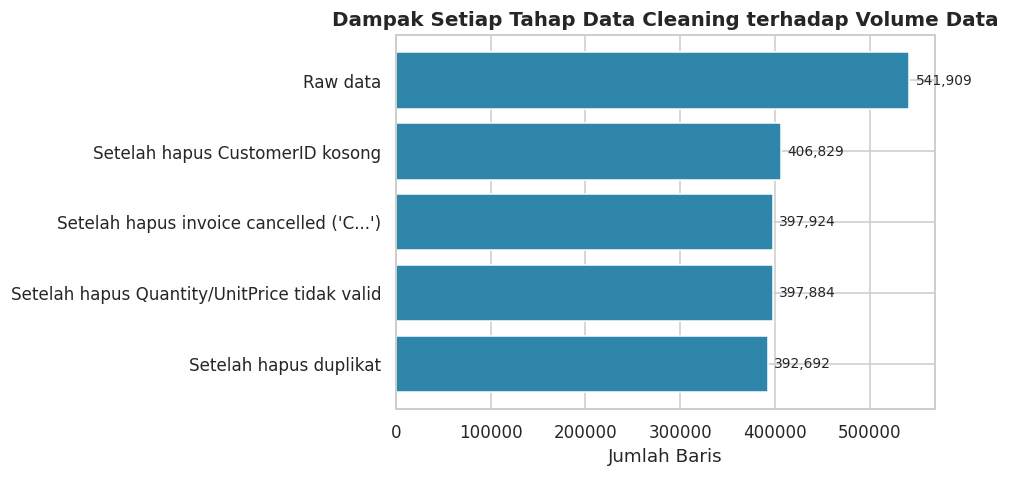

✅ Data cleaning selesai. 149,217 baris (27.54%) dihapus.
✅ Data bersih tersisa: 392,692 baris transaksi, 4,338 pelanggan unik.


In [28]:
# Visualisasi dampak cleaning terhadap volume data
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(log_df["Tahap"], log_df["Jumlah Baris"], color=PALETTE[0])
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=9)
ax.set_xlabel("Jumlah Baris")
ax.set_title("Dampak Setiap Tahap Data Cleaning terhadap Volume Data")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

total_removed = len(df_raw) - len(df)
print(f"✅ Data cleaning selesai. {total_removed:,} baris ({total_removed/len(df_raw)*100:.2f}%) dihapus.")
print(f"✅ Data bersih tersisa: {len(df):,} baris transaksi, {df['CustomerID'].nunique():,} pelanggan unik.")

## 🔎 4. Exploratory Data Analysis (Konteks Bisnis)

Sebelum membangun fitur RFM, kita lihat dulu gambaran umum data hasil cleaning: tren transaksi dari waktu ke waktu, kontribusi negara, dan produk terlaris. Ini memberi konteks bisnis yang akan berguna saat menafsirkan hasil cluster nanti.

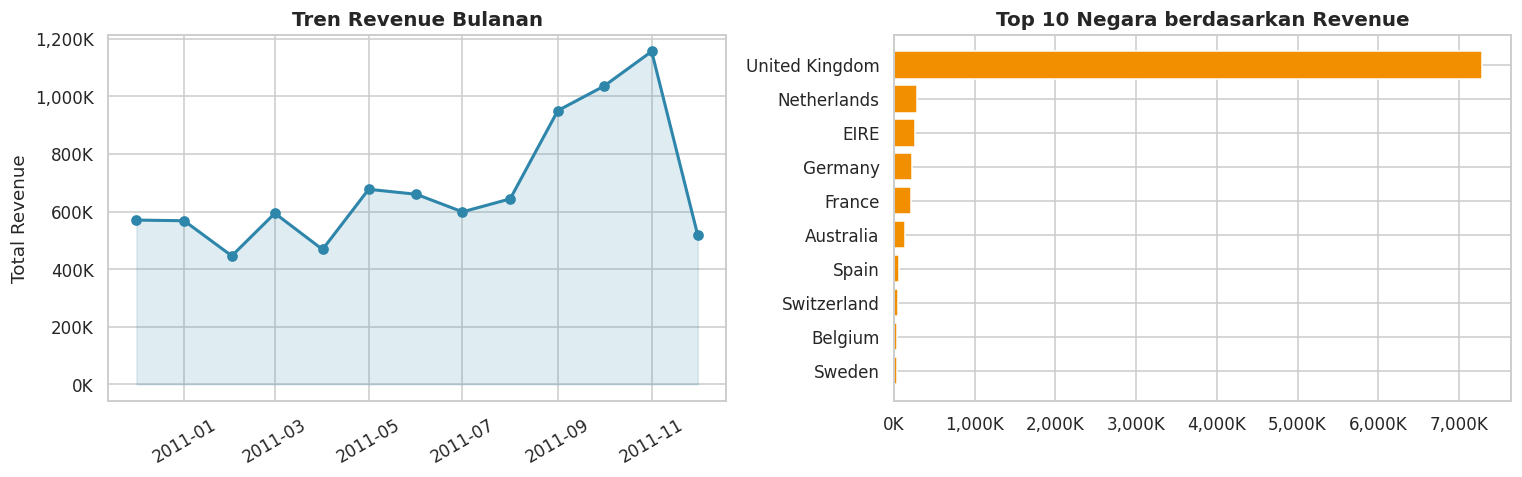

In [29]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

monthly_revenue = df.groupby("InvoiceMonth")["TotalPrice"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Tren revenue bulanan
axes[0].plot(monthly_revenue.index, monthly_revenue.values, marker="o", color=PALETTE[0], linewidth=2)
axes[0].fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.15, color=PALETTE[0])
axes[0].set_title("Tren Revenue Bulanan")
axes[0].set_ylabel("Total Revenue")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}K"))
axes[0].tick_params(axis="x", rotation=30)

# Top 10 negara berdasarkan revenue
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)
axes[1].barh(top_countries.index[::-1], top_countries.values[::-1], color=PALETTE[1])
axes[1].set_title("Top 10 Negara berdasarkan Revenue")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}K"))

plt.tight_layout()
plt.show()

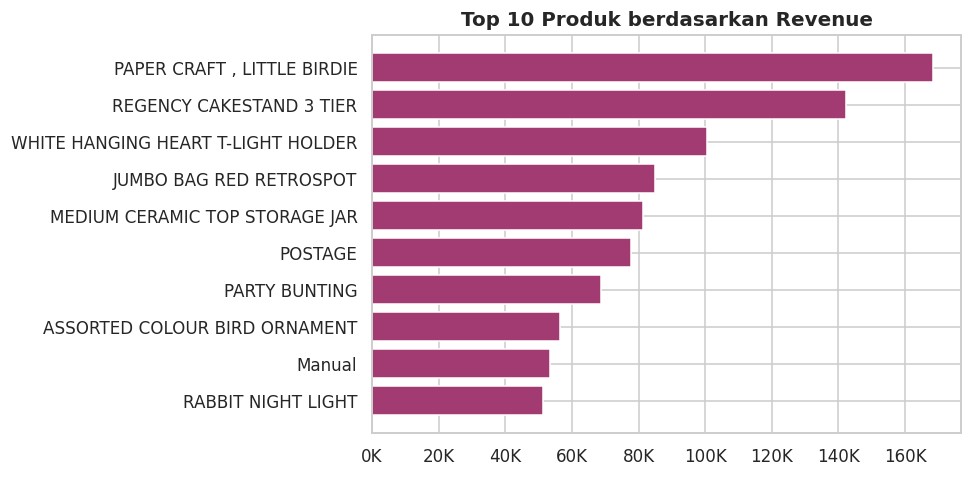

In [30]:
# Top 10 produk terlaris berdasarkan revenue
top_products = (
    df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(top_products.index[::-1], top_products.values[::-1], color=PALETTE[2])
ax.set_title("Top 10 Produk berdasarkan Revenue")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}K"))
plt.tight_layout()
plt.show()

## 🧮 5. RFM Feature Engineering

RFM mengubah data transaksi (level baris item) menjadi data **level pelanggan** melalui tiga metrik perilaku:

- **Recency (R):** Berapa hari sejak transaksi terakhir pelanggan (dihitung dari *snapshot date* = 1 hari setelah transaksi terakhir di dataset). Semakin **kecil**, semakin baik (baru saja belanja).
- **Frequency (F):** Jumlah invoice unik yang pernah dibuat pelanggan. Semakin **besar**, semakin baik (sering belanja).
- **Monetary (M):** Total nilai belanja pelanggan sepanjang periode data. Semakin **besar**, semakin baik (bernilai tinggi).

In [31]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
)

print(f"📅 Snapshot date  : {snapshot_date.date()}")
print(f"👥 Jumlah pelanggan (setelah agregasi RFM): {len(rfm):,}")
rfm.describe()

📅 Snapshot date  : 2011-12-10
👥 Jumlah pelanggan (setelah agregasi RFM): 4,338


,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,92.54,4.27,"2,048.69"
std,100.01,7.70,"8,985.23"
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,"1,660.60"
max,374.00,209.00,"280,206.02"


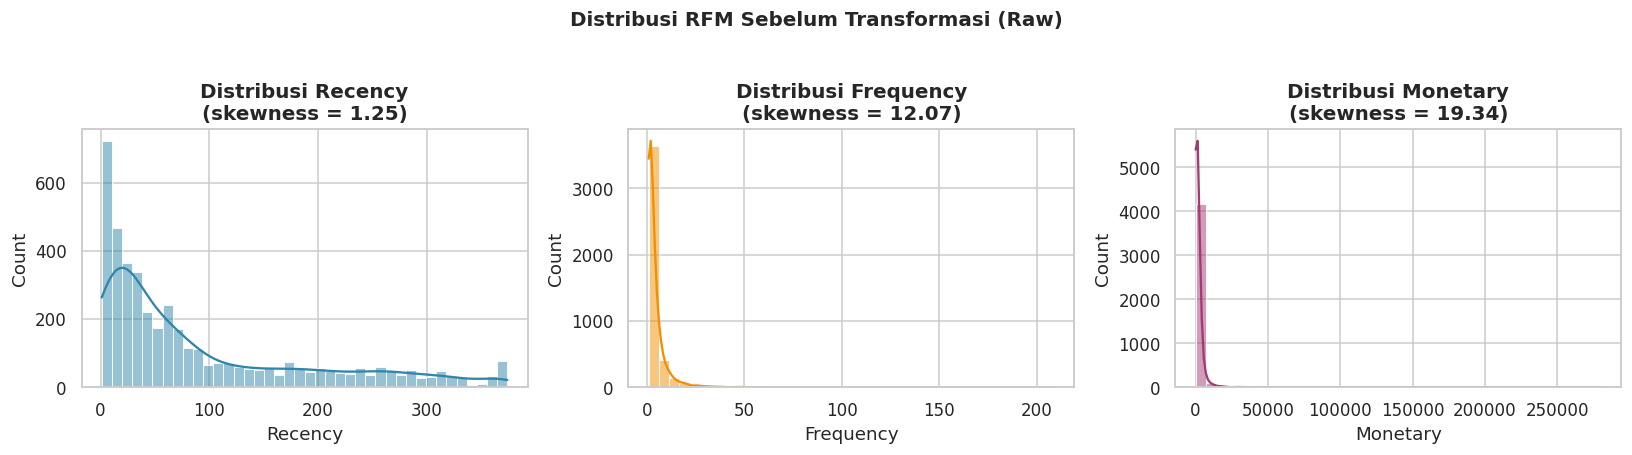

In [32]:
# Distribusi tiap komponen RFM sebelum transformasi -> cek skewness
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"], PALETTE):
    sns.histplot(rfm[col], bins=40, color=color, ax=ax, kde=True)
    skew = rfm[col].skew()
    ax.set_title(f"Distribusi {col}\n(skewness = {skew:.2f})")
plt.suptitle("Distribusi RFM Sebelum Transformasi (Raw)", y=1.03, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## ⚖️ 6. Standardization (Log Transform + StandardScaler)

Distribusi RFM pada data retail hampir selalu **right-skewed** (sedikit pelanggan dengan Frequency/Monetary sangat besar mendominasi rentang nilai). Jika langsung distandardisasi tanpa transformasi, K-Means (yang berbasis jarak Euclidean) akan sangat didominasi oleh fitur dengan skewness tinggi tersebut.

Strategi yang digunakan:
1. **Log transform** (`log1p`) pada ketiga fitur untuk mengurangi skewness dan meredam pengaruh nilai ekstrem.
2. **StandardScaler** agar ketiga fitur berada pada skala yang sebanding (mean = 0, std = 1) — supaya tidak ada satu fitur yang mendominasi perhitungan jarak hanya karena skalanya lebih besar.

In [33]:
rfm_log = rfm.copy()
for col in ["Recency", "Frequency", "Monetary"]:
    rfm_log[col] = np.log1p(rfm_log[col])

scaler = StandardScaler()
rfm_scaled_arr = scaler.fit_transform(rfm_log[["Recency", "Frequency", "Monetary"]])
rfm_scaled = pd.DataFrame(rfm_scaled_arr, columns=["Recency", "Frequency", "Monetary"], index=rfm.index)

rfm_scaled.describe()

,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.00
25%,-0.66,-0.96,-0.68
50%,0.09,-0.36,-0.07
75%,0.84,0.65,0.66
max,1.56,5.86,4.73


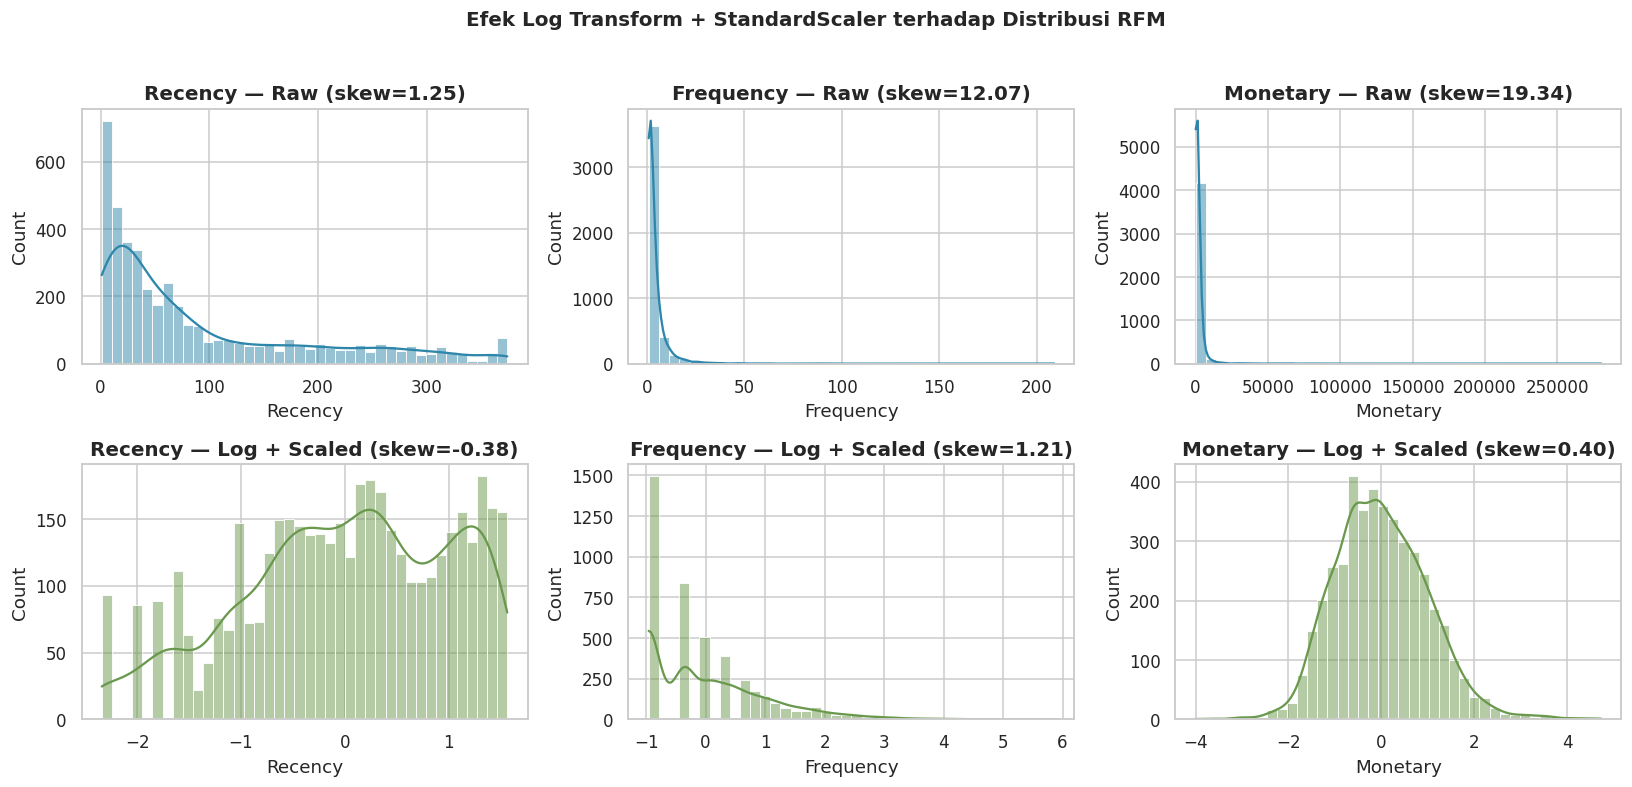

In [34]:
# Perbandingan distribusi sebelum vs sesudah log transform + scaling
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for j, col in enumerate(["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], bins=40, color=PALETTE[0], ax=axes[0, j], kde=True)
    axes[0, j].set_title(f"{col} — Raw (skew={rfm[col].skew():.2f})")

    sns.histplot(rfm_scaled[col], bins=40, color=PALETTE[3], ax=axes[1, j], kde=True)
    axes[1, j].set_title(f"{col} — Log + Scaled (skew={rfm_scaled[col].skew():.2f})")

plt.suptitle("Efek Log Transform + StandardScaler terhadap Distribusi RFM", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 📈 7. Outlier Analysis (Z-Score Based)

Setelah standardisasi, setiap nilai fitur **sudah berbentuk z-score** (jarak dalam satuan standar deviasi dari rata-rata). Ini membuat deteksi outlier menjadi langsung: pelanggan dengan `|z| > 3` pada salah satu dimensi RFM dianggap sebagai perilaku ekstrem (misalnya pembeli grosir/wholesaler yang jauh berbeda dari pelanggan retail biasa) yang dapat menarik centroid cluster secara tidak proporsional jika tidak ditangani.

Pelanggan-pelanggan ini **dikeluarkan dari proses clustering utama** agar segmentasi mencerminkan pola mayoritas pelanggan retail, bukan tertarik oleh segelintir kasus ekstrem.

In [35]:
Z_THRESHOLD = 3
outlier_mask = (rfm_scaled.abs() > Z_THRESHOLD).any(axis=1)

n_outliers = outlier_mask.sum()
print(f"🚨 Pelanggan terdeteksi sebagai outlier (|z| > {Z_THRESHOLD}): {n_outliers:,} dari {len(rfm_scaled):,} "
      f"({n_outliers/len(rfm_scaled)*100:.2f}%)")

rfm_scaled_final = rfm_scaled[~outlier_mask].copy()
rfm_final = rfm.loc[rfm_scaled_final.index].copy()

print(f"✅ Data final untuk clustering: {len(rfm_final):,} pelanggan")

🚨 Pelanggan terdeteksi sebagai outlier (|z| > 3): 67 dari 4,338 (1.54%)
✅ Data final untuk clustering: 4,271 pelanggan


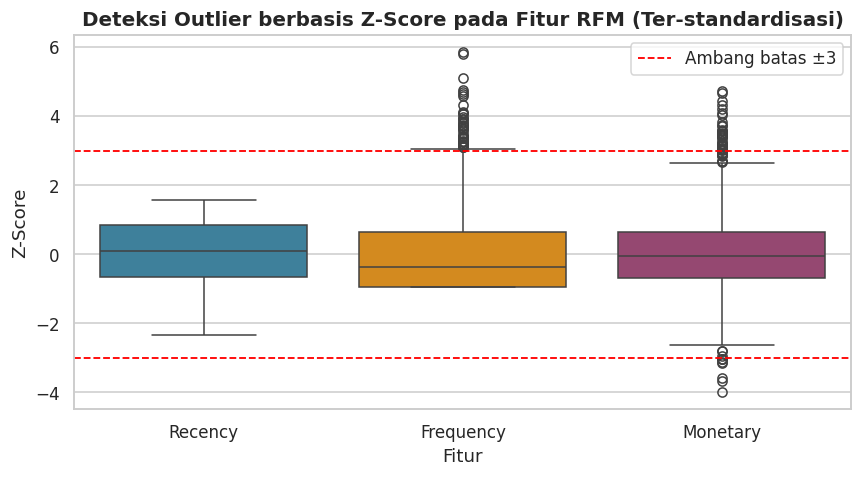

In [36]:
# Visualisasi boxplot z-score dengan garis ambang batas outlier
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = rfm_scaled.melt(var_name="Fitur", value_name="Z-Score")
sns.boxplot(data=plot_data, x="Fitur", y="Z-Score", ax=ax, palette=PALETTE[:3])
ax.axhline(Z_THRESHOLD, color="red", linestyle="--", linewidth=1.2, label=f"Ambang batas ±{Z_THRESHOLD}")
ax.axhline(-Z_THRESHOLD, color="red", linestyle="--", linewidth=1.2)
ax.set_title("Deteksi Outlier berbasis Z-Score pada Fitur RFM (Ter-standardisasi)")
ax.legend()
plt.tight_layout()
plt.show()

## 🎯 8. Optimal K Selection: Elbow + Silhouette + Calinski-Harabasz

Menentukan jumlah cluster optimal (**k**) adalah salah satu keputusan paling kritis — dan paling sering disalahpahami — dalam K-Means. Menggunakan **satu metrik saja berisiko menyesatkan**:

- **Silhouette Score** sering **maksimal di k=2**, karena secara matematis cara termudah untuk mendapatkan cluster yang "rapi" adalah memisahkan data menjadi dua kelompok besar (misalnya "pelanggan aktif" vs "pelanggan tidak aktif"). Ini valid secara statistik, tapi **terlalu kasar untuk kebutuhan bisnis** yang butuh membedakan, misalnya, "pelanggan loyal bernilai tinggi" vs "pelanggan baru berpotensi" vs "pelanggan berisiko churn".
- **Calinski-Harabasz Index** mengukur rasio variansi antar-cluster terhadap variansi dalam-cluster (semakin tinggi semakin baik) — cenderung lebih stabil terhadap jumlah cluster.
- **Davies-Bouldin Index** mengukur rata-rata kemiripan tiap cluster dengan cluster paling mirip lainnya (semakin **rendah** semakin baik) — melengkapi Silhouette & CH sebagai validasi silang.

**Strategi pengambilan keputusan pada notebook ini:** ketiga metrik (+Davies-Bouldin sebagai validasi tambahan) dihitung untuk k=2 sampai k=10, kemudian digabung menjadi **composite score** ternormalisasi. Rentang kandidat k dibatasi pada **k = 3 sampai 6** dengan dua pertimbangan bisnis sekaligus:
- **Batas bawah (k ≥ 3):** k=2 tidak cukup granular untuk *targeted marketing* — hanya memisahkan "aktif vs tidak aktif".
- **Batas atas (k ≤ 6):** lebih dari 6 segmen sulit dioperasionalkan tim marketing (terlalu banyak kampanye berbeda untuk dikelola), dan selaras dengan jumlah kategori segmen bisnis standar RFM (Champions, Loyal Customers, Potential Loyalists, At Risk, Hibernating, Needs Attention) yang dipakai pada Bagian 11.

**k direkomendasikan dari kandidat pada rentang tersebut** dengan composite score tertinggi — bukan dipilih sembarangan, dan bukan pula mengambil silhouette tertinggi secara membabi buta.

In [37]:
X = rfm_scaled_final.values
k_range = range(2, 11)

metric_records = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    metric_records.append({
        "k": k,
        "Inertia": km.inertia_,
        "Silhouette": silhouette_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
    })

metrics_df = pd.DataFrame(metric_records)
metrics_df.round(4)

,k,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,"5,627.58",0.43,"4,420.18",0.90
1,3,"4,276.39",0.33,"3,582.00",1.09
2,4,"3,365.39",0.34,"3,418.76",1.00
3,5,"2,848.99",0.32,"3,221.41",1.01
4,6,"2,442.23",0.31,"3,147.72",0.99
5,7,"2,208.39",0.31,"2,975.45",0.98
6,8,"2,009.87",0.31,"2,861.79",1.00
7,9,"1,850.86",0.28,"2,764.36",1.02
8,10,"1,717.29",0.28,"2,684.48",1.01


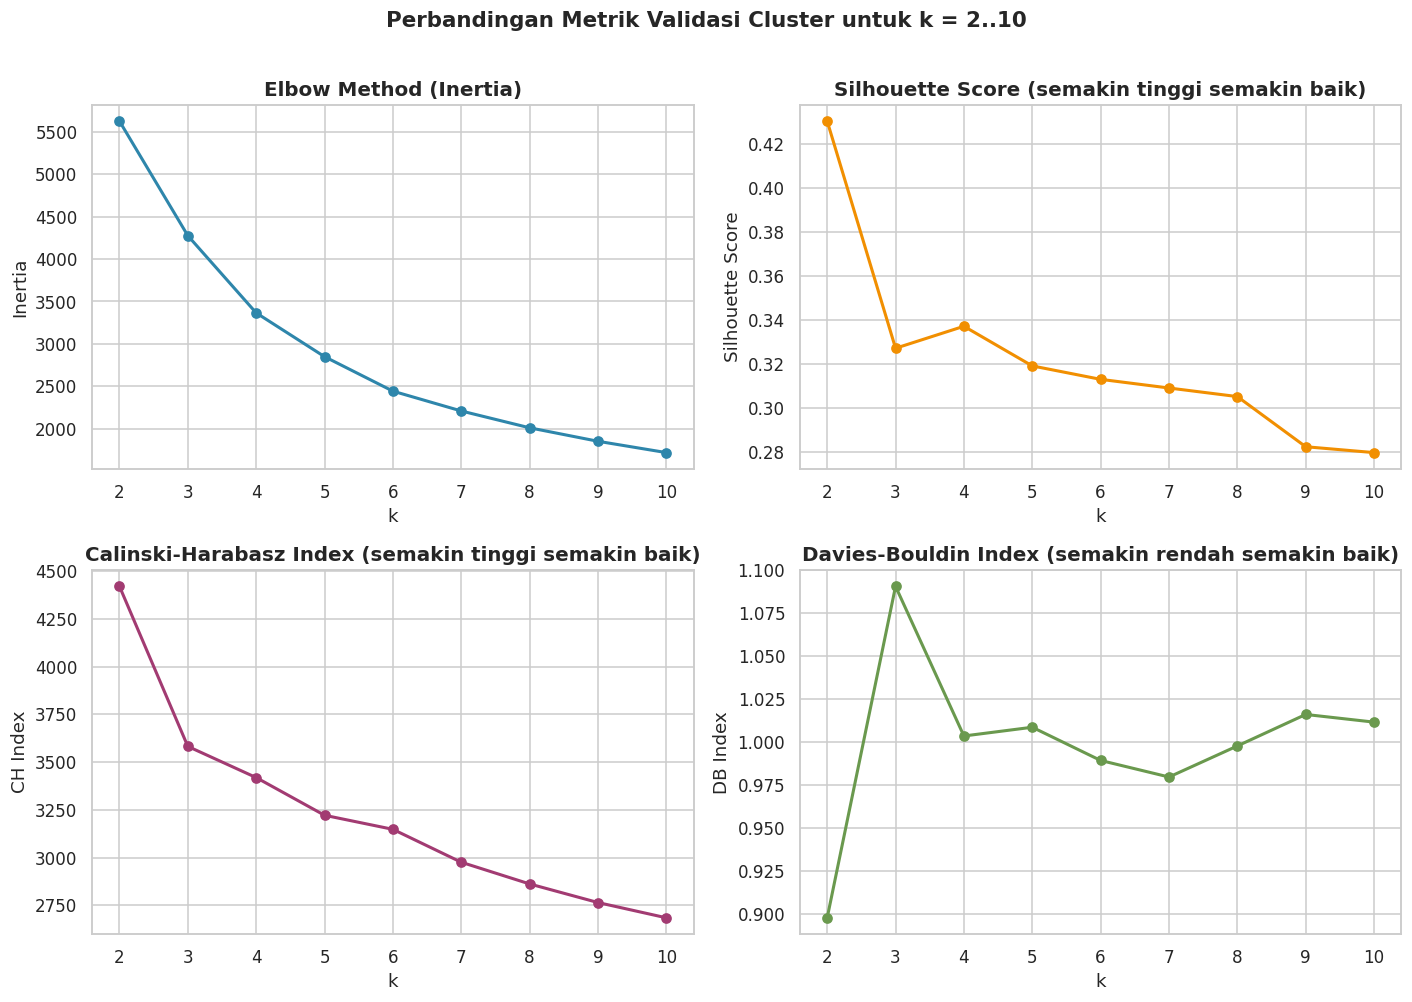

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(metrics_df["k"], metrics_df["Inertia"], marker="o", color=PALETTE[0], linewidth=2)
axes[0, 0].set_title("Elbow Method (Inertia)")
axes[0, 0].set_xlabel("k"); axes[0, 0].set_ylabel("Inertia")

axes[0, 1].plot(metrics_df["k"], metrics_df["Silhouette"], marker="o", color=PALETTE[1], linewidth=2)
axes[0, 1].set_title("Silhouette Score (semakin tinggi semakin baik)")
axes[0, 1].set_xlabel("k"); axes[0, 1].set_ylabel("Silhouette Score")

axes[1, 0].plot(metrics_df["k"], metrics_df["Calinski-Harabasz"], marker="o", color=PALETTE[2], linewidth=2)
axes[1, 0].set_title("Calinski-Harabasz Index (semakin tinggi semakin baik)")
axes[1, 0].set_xlabel("k"); axes[1, 0].set_ylabel("CH Index")

axes[1, 1].plot(metrics_df["k"], metrics_df["Davies-Bouldin"], marker="o", color=PALETTE[3], linewidth=2)
axes[1, 1].set_title("Davies-Bouldin Index (semakin rendah semakin baik)")
axes[1, 1].set_xlabel("k"); axes[1, 1].set_ylabel("DB Index")

plt.suptitle("Perbandingan Metrik Validasi Cluster untuk k = 2..10", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [39]:
# ----- Composite decision score -----
scored = metrics_df.copy()

def normalize(series, higher_is_better=True):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0 + 1.0
    norm = (series - mn) / (mx - mn)
    return norm if higher_is_better else 1 - norm

scored["Silhouette_norm"] = normalize(scored["Silhouette"], True)
scored["CH_norm"] = normalize(scored["Calinski-Harabasz"], True)
scored["DB_norm"] = normalize(scored["Davies-Bouldin"], False)
scored["Composite Score"] = scored[["Silhouette_norm", "CH_norm", "DB_norm"]].mean(axis=1)

MIN_BUSINESS_K = 3  # granularitas minimum agar segmen actionable untuk strategi pemasaran
MAX_BUSINESS_K = 6  # batas atas agar segmen tetap bisa dioperasionalkan tim marketing
candidates = scored[(scored["k"] >= MIN_BUSINESS_K) & (scored["k"] <= MAX_BUSINESS_K)]
candidates = candidates.sort_values("Composite Score", ascending=False)

OPTIMAL_K = int(candidates.iloc[0]["k"])

display_cols = ["k", "Silhouette", "Calinski-Harabasz", "Davies-Bouldin", "Composite Score"]
(
    scored[display_cols]
    .style
    .background_gradient(subset=["Composite Score"], cmap="Greens")
    .format({"Silhouette": "{:.4f}", "Calinski-Harabasz": "{:.1f}", "Davies-Bouldin": "{:.4f}", "Composite Score": "{:.4f}"})
)

,k,Silhouette,Calinski-Harabasz,Davies-Bouldin,Composite Score
0,2,0.4304,4420.2,0.8980,1.0000
1,3,0.3271,3582.0,1.0906,0.2773
2,4,0.3371,3418.8,1.0036,0.4185
3,5,0.3191,3221.4,1.0087,0.3320
4,6,0.3130,3147.7,0.9894,0.3377
5,7,0.3090,2975.5,0.9798,0.3126
6,8,0.3051,2861.8,0.9978,0.2509
7,9,0.2823,2764.4,1.0161,0.1501
8,10,0.2796,2684.5,1.0117,0.1366


In [40]:
sil_k2 = scored.loc[scored["k"] == 2, "Silhouette"].values[0]
sil_opt = scored.loc[scored["k"] == OPTIMAL_K, "Silhouette"].values[0]

print("="*72)
print("📌 KEPUTUSAN PEMILIHAN K")
print("="*72)
print(f"Silhouette tertinggi murni terjadi di k=2 (score = {sil_k2:.4f}), namun k=2 hanya")
print("menghasilkan dua kelompok besar yang terlalu kasar untuk kebutuhan segmentasi bisnis")
print("(tidak cukup granular untuk targeted marketing).")
print()
print(f"Dengan mempertimbangkan composite score (Silhouette + Calinski-Harabasz + Davies-Bouldin)")
print(f"pada kandidat k = {MIN_BUSINESS_K}..{MAX_BUSINESS_K} (rentang granularitas yang actionable")
print("secara bisnis), k optimal terpilih:")
print()
print(f"   >>> OPTIMAL_K = {OPTIMAL_K}  (Silhouette = {sil_opt:.4f}, Composite Score = "
      f"{candidates.iloc[0]['Composite Score']:.4f}) <<<")
print("="*72)

📌 KEPUTUSAN PEMILIHAN K
Silhouette tertinggi murni terjadi di k=2 (score = 0.4304), namun k=2 hanya
menghasilkan dua kelompok besar yang terlalu kasar untuk kebutuhan segmentasi bisnis
(tidak cukup granular untuk targeted marketing).

Dengan mempertimbangkan composite score (Silhouette + Calinski-Harabasz + Davies-Bouldin)
pada kandidat k = 3..6 (rentang granularitas yang actionable
secara bisnis), k optimal terpilih:

   >>> OPTIMAL_K = 4  (Silhouette = 0.3371, Composite Score = 0.4185) <<<


## 🤖 9. K-Means Clustering (Final Model)

Melatih model K-Means final menggunakan `OPTIMAL_K` yang telah ditentukan secara objektif pada tahap sebelumnya.

In [41]:
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X)

rfm_scaled_final["Cluster"] = cluster_labels
rfm_final["Cluster"] = rfm_scaled_final["Cluster"]  # digabung berdasarkan index (aman & selalu align)

cluster_sizes = rfm_final["Cluster"].value_counts().sort_index()
cluster_pct = (cluster_sizes / len(rfm_final) * 100).round(1)

summary_sizes = pd.DataFrame({"Jumlah Pelanggan": cluster_sizes, "% dari Total": cluster_pct})
print(f"✅ Model K-Means final dilatih dengan k = {OPTIMAL_K}")
print(f"✅ Silhouette Score model final: {silhouette_score(X, cluster_labels):.4f}")
summary_sizes

✅ Model K-Means final dilatih dengan k = 4
✅ Silhouette Score model final: 0.3371


,Jumlah Pelanggan,% dari Total
Cluster,,
0,874,20.50
1,1139,26.70
2,1447,33.90
3,811,19.00


## 🧬 10. Cluster Profiling

Menganalisis karakteristik rata-rata (dan median) tiap cluster pada dimensi Recency, Frequency, dan Monetary — untuk memahami "siapa" penghuni tiap cluster sebelum diberi nama segmen bisnis.

In [42]:
cluster_summary = rfm_final.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].agg(["mean", "median"])
cluster_summary.columns = ["_".join(c) for c in cluster_summary.columns]
cluster_summary.insert(0, "Jumlah Pelanggan", cluster_sizes)
cluster_summary.round(1)

,Jumlah Pelanggan,Recency_mean,Recency_median,Frequency_mean,Frequency_median,Monetary_mean,Monetary_median
Cluster,,,,,,,
0,874,22.50,20.00,1.90,2.00,464.90,399.10
1,1139,75.40,60.00,3.80,4.00,"1,552.70","1,240.10"
2,1447,195.20,191.00,1.30,1.00,333.40,290.40
3,811,12.80,9.00,9.80,8.00,"4,111.30","2,919.80"


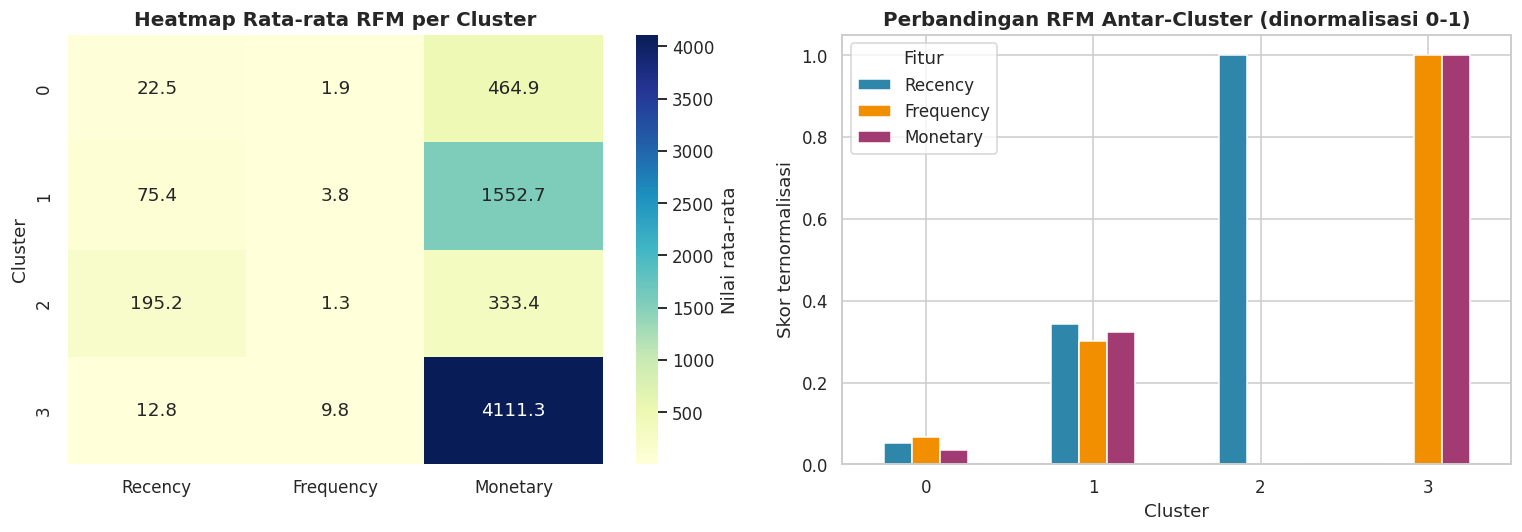

In [43]:
cluster_means = rfm_final.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap rata-rata (raw) per cluster
sns.heatmap(cluster_means, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "Nilai rata-rata"})
axes[0].set_title("Heatmap Rata-rata RFM per Cluster")

# Bar chart RFM (dinormalisasi 0-1 agar 3 skala berbeda bisa dibandingkan visual)
norm_means = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
norm_means.plot(kind="bar", ax=axes[1], color=PALETTE[:3])
axes[1].set_title("Perbandingan RFM Antar-Cluster (dinormalisasi 0-1)")
axes[1].set_ylabel("Skor ternormalisasi")
axes[1].set_xlabel("Cluster")
axes[1].legend(title="Fitur")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

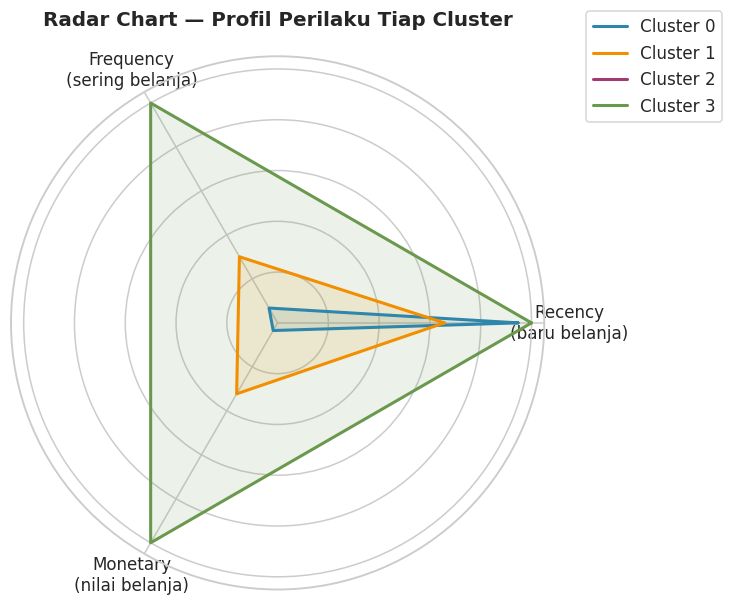

In [44]:
# Radar chart profil tiap cluster (Recency dibalik agar "tinggi = baik" pada seluruh sumbu)
radar_df = cluster_means.copy()
radar_df["Recency_score"] = 1 - (radar_df["Recency"] - radar_df["Recency"].min()) / (radar_df["Recency"].max() - radar_df["Recency"].min() + 1e-9)
radar_df["Frequency_score"] = (radar_df["Frequency"] - radar_df["Frequency"].min()) / (radar_df["Frequency"].max() - radar_df["Frequency"].min() + 1e-9)
radar_df["Monetary_score"] = (radar_df["Monetary"] - radar_df["Monetary"].min()) / (radar_df["Monetary"].max() - radar_df["Monetary"].min() + 1e-9)

categories = ["Recency_score", "Frequency_score", "Monetary_score"]
labels_ring = ["Recency\n(baru belanja)", "Frequency\n(sering belanja)", "Monetary\n(nilai belanja)"]
n_cat = len(categories)
angles = [n / float(n_cat) * 2 * pi for n in range(n_cat)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i, (idx, row) in enumerate(radar_df.iterrows()):
    values = row[categories].tolist()
    values += values[:1]
    color = PALETTE[i % len(PALETTE)]
    ax.plot(angles, values, linewidth=2, label=f"Cluster {idx}", color=color)
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_ring)
ax.set_yticklabels([])
ax.set_title("Radar Chart — Profil Perilaku Tiap Cluster", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

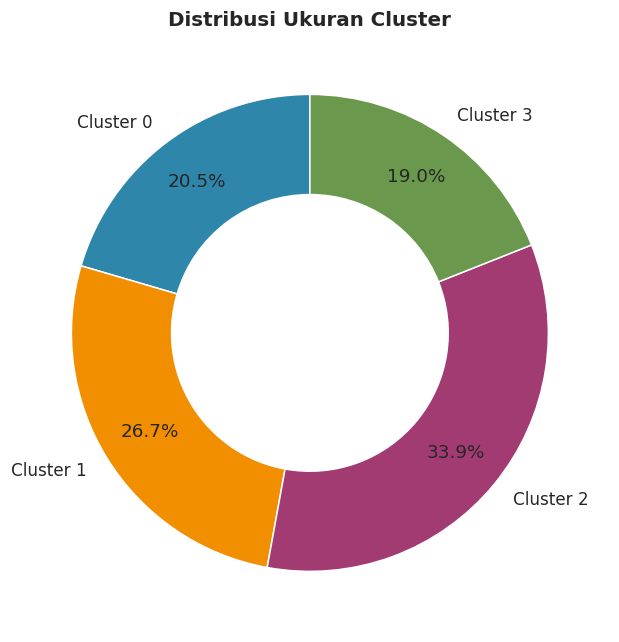

In [45]:
# Distribusi ukuran cluster (donut chart)
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    cluster_sizes.values,
    labels=[f"Cluster {c}" for c in cluster_sizes.index],
    autopct="%1.1f%%",
    colors=PALETTE[:len(cluster_sizes)],
    wedgeprops=dict(width=0.42, edgecolor="white"),
    pctdistance=0.79,
    startangle=90,
)
ax.set_title("Distribusi Ukuran Cluster", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 🗺️ 11. Business Segment Interpretation

Cluster hasil K-Means hanyalah label angka (0, 1, 2, ...) — belum bermakna secara bisnis. Tahap ini menerjemahkan posisi relatif tiap cluster pada dimensi RFM menjadi **nama segmen bisnis yang umum digunakan dalam praktik CRM/marketing**, menggunakan aturan berbasis skor relatif (bukan angka tetap yang di-hardcode), sehingga logika ini tetap valid meskipun jumlah/nilai cluster berubah saat notebook dijalankan ulang dengan data lain.

In [46]:
def label_segment(row):
    r, f, m = row["Recency_score"], row["Frequency_score"], row["Monetary_score"]
    if r >= 0.66 and f >= 0.66 and m >= 0.66:
        return "Champions"
    elif r >= 0.66 and (f >= 0.33 or m >= 0.5):
        return "Loyal Customers"
    elif r < 0.33 and (f >= 0.5 or m >= 0.5):
        return "At Risk"
    elif r < 0.33 and f < 0.33 and m < 0.33:
        return "Hibernating / Lost"
    elif f >= 0.5 or m >= 0.5:
        return "Potential Loyalists"
    else:
        return "Needs Attention"

radar_df["Segment"] = radar_df.apply(label_segment, axis=1)
segment_map = radar_df["Segment"].to_dict()

rfm_final["Segment"] = rfm_final["Cluster"].map(segment_map)

# Tabel ringkasan final per segmen
segment_table = rfm_final.groupby("Segment").agg(
    Jumlah_Pelanggan=("Cluster", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum"),
).sort_values("Total_Revenue", ascending=False)

segment_table["% Pelanggan"] = (segment_table["Jumlah_Pelanggan"] / len(rfm_final) * 100).round(1)
segment_table["% Revenue"] = (segment_table["Total_Revenue"] / segment_table["Total_Revenue"].sum() * 100).round(1)
segment_table = segment_table[["Jumlah_Pelanggan", "% Pelanggan", "Avg_Recency", "Avg_Frequency",
                                "Avg_Monetary", "Total_Revenue", "% Revenue"]]

(
    segment_table.style
    .background_gradient(subset=["% Revenue"], cmap="Oranges")
    .background_gradient(subset=["% Pelanggan"], cmap="Blues")
    .format({"Avg_Recency": "{:.1f}", "Avg_Frequency": "{:.1f}", "Avg_Monetary": "{:,.0f}",
              "Total_Revenue": "{:,.0f}", "% Pelanggan": "{:.1f}%", "% Revenue": "{:.1f}%"})
)

,Jumlah_Pelanggan,% Pelanggan,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,% Revenue
Segment,,,,,,,
Champions,811,19.0%,12.8,9.8,"4,111","3,334,282",55.6%
Needs Attention,2013,47.1%,52.5,3.0,"1,080","2,174,920",36.3%
Hibernating / Lost,1447,33.9%,195.2,1.3,333,"482,486",8.1%


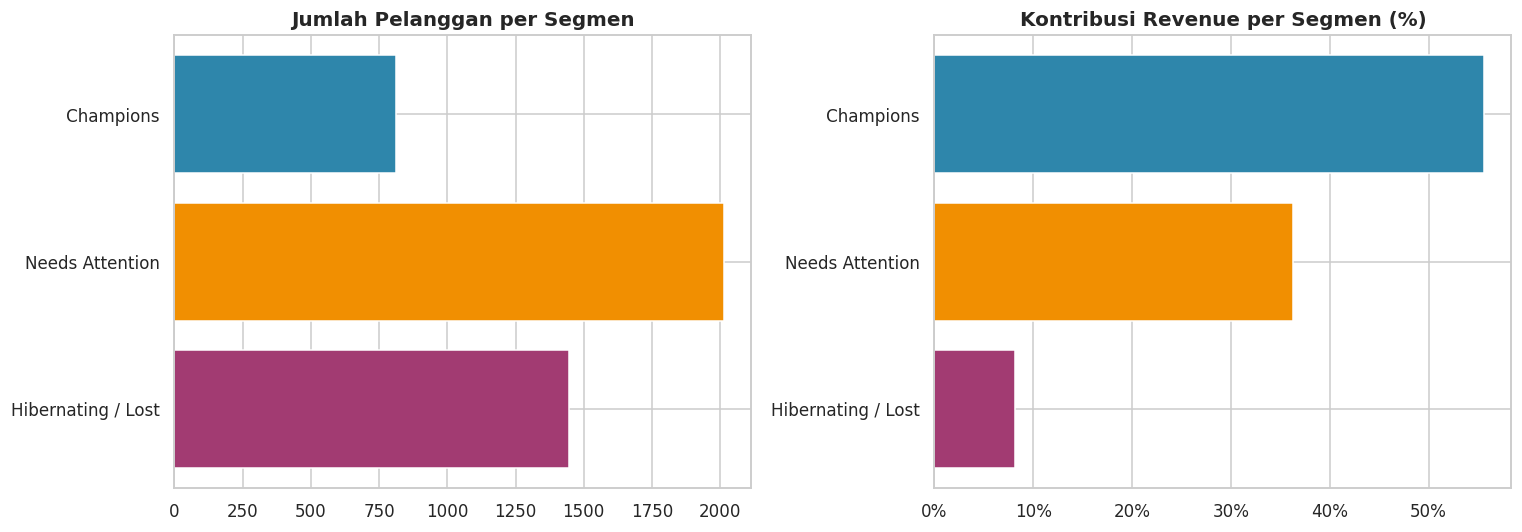

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = segment_table.index
seg_colors = PALETTE[:len(order)]

axes[0].barh(order, segment_table["Jumlah_Pelanggan"], color=seg_colors)
axes[0].set_title("Jumlah Pelanggan per Segmen")
axes[0].invert_yaxis()

axes[1].barh(order, segment_table["% Revenue"], color=seg_colors)
axes[1].set_title("Kontribusi Revenue per Segmen (%)")
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

## 🌐 12. PCA 2D Visualization

Fitur RFM ter-standardisasi berada di ruang 3 dimensi. **Principal Component Analysis (PCA)** mereduksinya menjadi 2 dimensi agar seluruh struktur cluster dapat divisualisasikan sekaligus dalam satu scatter plot, lengkap dengan titik pusat (centroid) tiap cluster.

📐 Variansi yang dijelaskan PC1: 73.5% | PC2: 20.4% | Total: 93.9%


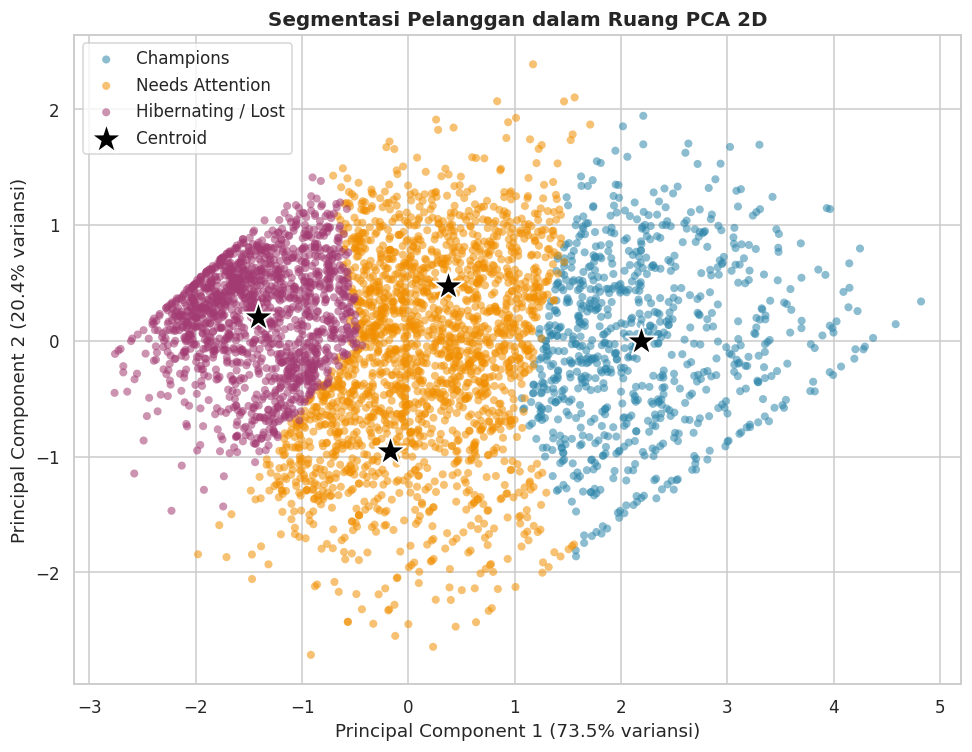

In [48]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X)
centroids_pca = pca.transform(kmeans_final.cluster_centers_)

explained = pca.explained_variance_ratio_
print(f"📐 Variansi yang dijelaskan PC1: {explained[0]*100:.1f}% | PC2: {explained[1]*100:.1f}% "
      f"| Total: {explained.sum()*100:.1f}%")

plot_df = pd.DataFrame(pca_coords, columns=["PC1", "PC2"], index=rfm_final.index)
plot_df["Segment"] = rfm_final["Segment"].values

fig, ax = plt.subplots(figsize=(9, 7))
segments_sorted = segment_table.index.tolist()
palette_map = {seg: PALETTE[i % len(PALETTE)] for i, seg in enumerate(segments_sorted)}

for seg in segments_sorted:
    sub = plot_df[plot_df["Segment"] == seg]
    ax.scatter(sub["PC1"], sub["PC2"], s=28, alpha=0.55, color=palette_map[seg], label=seg, edgecolor="none")

ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker="*", s=450, color="black",
           edgecolor="white", linewidth=1.2, label="Centroid", zorder=5)

ax.set_xlabel(f"Principal Component 1 ({explained[0]*100:.1f}% variansi)")
ax.set_ylabel(f"Principal Component 2 ({explained[1]*100:.1f}% variansi)")
ax.set_title("Segmentasi Pelanggan dalam Ruang PCA 2D", fontsize=13, fontweight="bold")
ax.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()

## 💡 13. Business Recommendations

Setiap segmen memiliki karakteristik perilaku yang berbeda, sehingga membutuhkan **strategi pemasaran yang berbeda pula**. Tabel berikut memetakan tiap segmen ke rekomendasi aksi bisnis yang konkret.

In [49]:
recommendation_map = {
    "Champions": "Berikan program loyalitas eksklusif, akses awal produk baru (early access), dan penawaran VIP. Jadikan mereka brand advocate lewat program referral.",
    "Loyal Customers": "Pertahankan engagement dengan poin loyalitas & penawaran personal. Dorong peningkatan frekuensi belanja lewat bundling atau subscription.",
    "Potential Loyalists": "Berikan insentif onboarding (diskon pembelian ke-2/ke-3) dan komunikasi rutin untuk membangun kebiasaan belanja berulang.",
    "At Risk": "Jalankan kampanye win-back: email/promo personalisasi, diskon terbatas waktu, atau survei alasan penurunan aktivitas.",
    "Hibernating / Lost": "Prioritaskan biaya pemasaran rendah (reactivation campaign massal) atau alihkan budget ke segmen lain yang lebih responsif.",
    "Needs Attention": "Pantau tren perilaku secara berkala; berikan promosi bertarget untuk mencegah pelanggan bergeser ke segmen 'At Risk'.",
}

segment_table_display = segment_table.copy()
segment_table_display["Rekomendasi Strategi"] = segment_table_display.index.map(
    lambda s: recommendation_map.get(s, "Pantau perilaku segmen ini secara berkala.")
)

for seg, row in segment_table_display.iterrows():
    print(f"🔹 {seg}  ({row['Jumlah_Pelanggan']:,} pelanggan | {row['% Pelanggan']}% populasi | "
          f"{row['% Revenue']}% kontribusi revenue)")
    print(f"   → {row['Rekomendasi Strategi']}")
    print()

🔹 Champions  (811 pelanggan | 19.0% populasi | 55.6% kontribusi revenue)
   → Berikan program loyalitas eksklusif, akses awal produk baru (early access), dan penawaran VIP. Jadikan mereka brand advocate lewat program referral.

🔹 Needs Attention  (2,013 pelanggan | 47.1% populasi | 36.3% kontribusi revenue)
   → Pantau tren perilaku secara berkala; berikan promosi bertarget untuk mencegah pelanggan bergeser ke segmen 'At Risk'.

🔹 Hibernating / Lost  (1,447 pelanggan | 33.9% populasi | 8.1% kontribusi revenue)
   → Prioritaskan biaya pemasaran rendah (reactivation campaign massal) atau alihkan budget ke segmen lain yang lebih responsif.



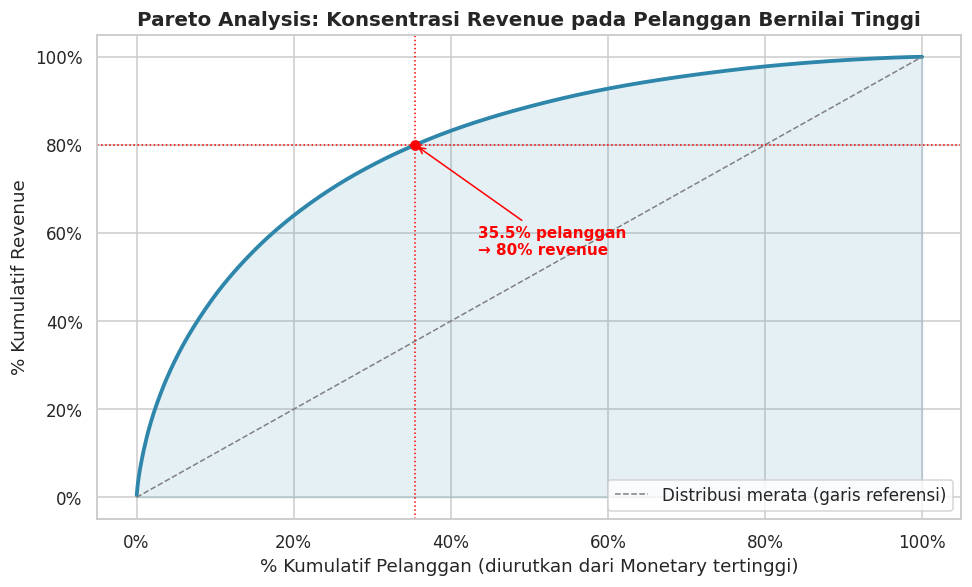

💰 Insight: sekitar 35.5% pelanggan (biasanya didominasi segmen Champions & Loyal Customers) menyumbang 80% dari total revenue.


In [50]:
# Pareto chart: kontribusi revenue kumulatif berdasarkan urutan pelanggan ter-bernilai
rfm_sorted = rfm_final.sort_values("Monetary", ascending=False).reset_index(drop=True)
rfm_sorted["cum_customer_pct"] = (rfm_sorted.index + 1) / len(rfm_sorted) * 100
rfm_sorted["cum_revenue_pct"] = rfm_sorted["Monetary"].cumsum() / rfm_sorted["Monetary"].sum() * 100

# insight: berapa % pelanggan yang berkontribusi 80% revenue
idx_80 = (rfm_sorted["cum_revenue_pct"] >= 80).idxmax()
pct_customers_for_80 = rfm_sorted.loc[idx_80, "cum_customer_pct"]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(rfm_sorted["cum_customer_pct"], rfm_sorted["cum_revenue_pct"], color=PALETTE[0], linewidth=2.5)
ax.fill_between(rfm_sorted["cum_customer_pct"], rfm_sorted["cum_revenue_pct"], alpha=0.12, color=PALETTE[0])
ax.plot([0, 100], [0, 100], linestyle="--", color="gray", linewidth=1, label="Distribusi merata (garis referensi)")

ax.axhline(80, color="red", linestyle=":", linewidth=1)
ax.axvline(pct_customers_for_80, color="red", linestyle=":", linewidth=1)
ax.scatter([pct_customers_for_80], [80], color="red", zorder=5)
ax.annotate(f"{pct_customers_for_80:.1f}% pelanggan\n→ 80% revenue",
            xy=(pct_customers_for_80, 80), xytext=(pct_customers_for_80 + 8, 55),
            arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=10, fontweight="bold")

ax.set_xlabel("% Kumulatif Pelanggan (diurutkan dari Monetary tertinggi)")
ax.set_ylabel("% Kumulatif Revenue")
ax.set_title("Pareto Analysis: Konsentrasi Revenue pada Pelanggan Bernilai Tinggi")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"💰 Insight: sekitar {pct_customers_for_80:.1f}% pelanggan (biasanya didominasi segmen "
      f"Champions & Loyal Customers) menyumbang 80% dari total revenue.")

## 📌 14. Executive Summary & Kesimpulan

In [51]:
top_segment_revenue = segment_table["% Revenue"].idxmax()
top_segment_size = segment_table["Jumlah_Pelanggan"].idxmax()
total_revenue_analyzed = df["TotalPrice"].sum()

print("="*78)
print("RINGKASAN AKHIR — RFM-BASED CUSTOMER SEGMENTATION")
print("="*78)
print(f"• Periode data                 : {df['InvoiceDate'].min().date()} s.d. {df['InvoiceDate'].max().date()}")
print(f"• Total transaksi bersih       : {len(df):,} baris")
print(f"• Total revenue dianalisis     : {total_revenue_analyzed:,.0f}")
print(f"• Pelanggan dianalisis         : {len(rfm_final):,} (setelah outlier removal)")
print(f"• Jumlah segmen optimal (k)    : {OPTIMAL_K}  (dipilih via composite score, bukan silhouette semata)")
print(f"• Silhouette Score model final : {silhouette_score(X, cluster_labels):.4f}")
print(f"• Segmen dengan populasi terbesar : {top_segment_size} "
      f"({segment_table.loc[top_segment_size, 'Jumlah_Pelanggan']:,} pelanggan)")
print(f"• Segmen penyumbang revenue terbesar : {top_segment_revenue} "
      f"({segment_table.loc[top_segment_revenue, '% Revenue']}% dari total revenue)")
print("="*78)

RINGKASAN AKHIR — RFM-BASED CUSTOMER SEGMENTATION
• Periode data                 : 2010-12-01 s.d. 2011-12-09
• Total transaksi bersih       : 392,692 baris
• Total revenue dianalisis     : 8,887,209
• Pelanggan dianalisis         : 4,271 (setelah outlier removal)
• Jumlah segmen optimal (k)    : 4  (dipilih via composite score, bukan silhouette semata)
• Silhouette Score model final : 0.3371
• Segmen dengan populasi terbesar : Needs Attention (2,013 pelanggan)
• Segmen penyumbang revenue terbesar : Champions (55.6% dari total revenue)


### 🔭 Keterbatasan & Pengembangan Lanjutan

- **Snapshot tunggal:** RFM dihitung dari satu titik waktu (snapshot date). Untuk validasi kestabilan segmen dari waktu ke waktu, analisis bisa diulang secara periodik (misalnya bulanan) dan dibandingkan (*cluster stability analysis*).
- **Threshold aturan segmentasi:** Ambang batas pada `label_segment()` (0.33/0.5/0.66) merupakan heuristik umum RFM; dapat dikalibrasi lebih lanjut bersama tim bisnis/marketing agar selaras dengan strategi perusahaan.
- **Perbandingan algoritma:** K-Means mengasumsikan cluster berbentuk bulat (spherical) dan berukuran relatif sama. Sebagai pembanding, dapat dicoba algoritma lain seperti **Gaussian Mixture Model**, **DBSCAN**, atau **Hierarchical Clustering**, lalu dibandingkan performanya dengan metrik yang sama.
- **Prediktif, bukan hanya deskriptif:** Segmentasi ini bersifat deskriptif (menjelaskan pola masa lalu). Pengembangan lanjutan bisa mengarah ke model prediktif seperti **Customer Lifetime Value (CLV) forecasting** atau **churn prediction**.
- **Aktivasi bisnis:** Hasil segmen idealnya diintegrasikan ke sistem CRM agar rekomendasi strategi di Bagian 13 dapat langsung dieksekusi oleh tim marketing (mis. sebagai audience list untuk campaign email).

---
*Notebook ini disusun sebagai proyek data mining dengan pendekatan end-to-end data science: dari data mentah hingga rekomendasi bisnis yang dapat ditindaklanjuti.*